<a href="https://colab.research.google.com/github/Yahir-7/Data_Center_GeoPandas/blob/main/Extreme_Heat.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

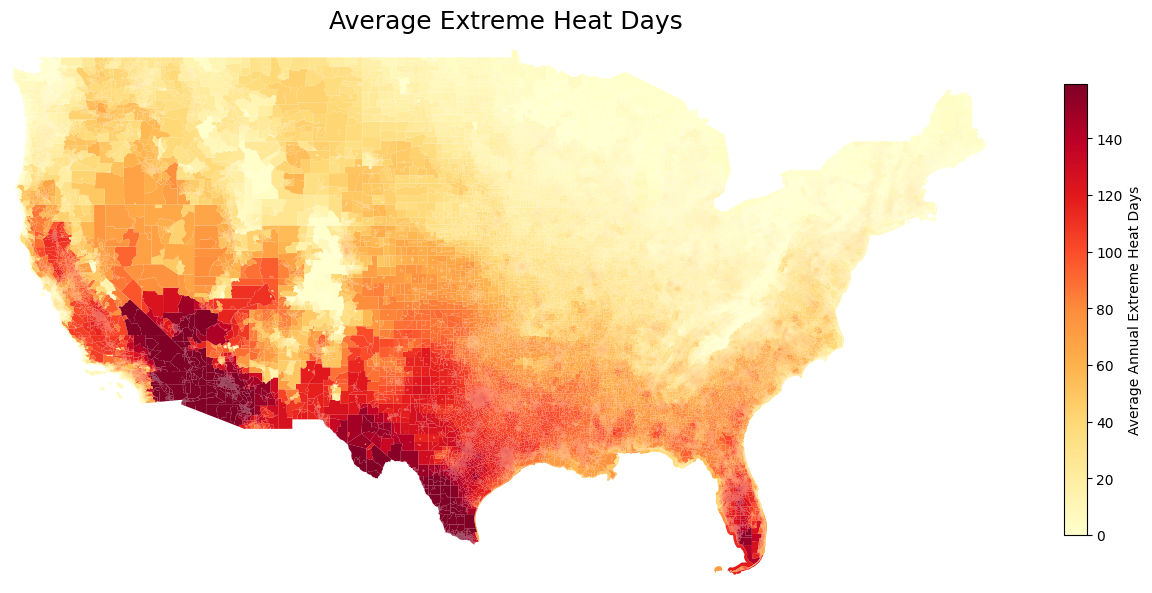

In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import box

ejs = gpd.read_file("/content/EJScreen_HI.shp")

# Make sure CRS is latitude/longitude
ejs = ejs.to_crs(epsg=4326)
# print (ejs.columns)
# ejs.head()

# Bounding box for lower 48 states
lower48_box = box(-125, 24, -66, 50)

# Keep only polygons that intersect the lower 48 box
lower48 = ejs[ejs.intersects(lower48_box)].copy()

# Optional: clip shapes exactly to the box
lower48 = gpd.clip(lower48, lower48_box)
# print(lower48[[ "STATE_NAME", "Days_Above", "Days_Abo_1", "Days_Abo_2", "Days_Abo_3", "Days_Abo_4", "Max_Days_A", "Average_Da" ]].head())

# Make colors look better by ignoring extreme outliers
vmin = lower48["Average_Da"].quantile(0.02)
vmax = lower48["Average_Da"].quantile(0.98)

fig, ax = plt.subplots(figsize=(16, 9))

lower48.plot(
    column="Average_Da",
    cmap="YlOrRd",
    legend=True,
    edgecolor="none",
    linewidth=0,
    vmin=vmin,
    vmax=vmax,
    ax=ax,
    legend_kwds={
        "label": "Average Annual Extreme Heat Days",
        "shrink": 0.65
    }
)

ax.set_xlim(-125, -66)
ax.set_ylim(24, 50)
ax.set_title("Average Extreme Heat Days", fontsize=18)
ax.axis("off")

plt.show()